In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display plots inside notebook
%matplotlib inline

In [6]:
import pandas as pd
df = pd.read_csv("Loan.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,id,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,...,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1,high_interest_rate,senior_age
0,126324,151214,2019,ncf,Male,nopre,type1,p3,l1,nopc,...,EXP,35-44,to_inst,70.063920,North,direct,0.0,42.0,1.0,0.0
1,13385,38275,2019,cf,Joint,nopre,type1,p4,l1,nopc,...,EXP,>74,not_inst,40.327381,North,direct,0.0,40.0,0.0,1.0
2,98606,123496,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,...,CIB,55-64,to_inst,49.260355,south,direct,0.0,29.0,1.0,1.0
3,7184,32074,2019,cf,Female,nopre,type1,p3,l1,nopc,...,CIB,35-44,to_inst,74.280576,North,direct,0.0,44.0,1.0,0.0
4,120745,145635,2019,cf,Male,nopre,type1,p1,l1,nopc,...,CIB,35-44,not_inst,99.107143,North,direct,0.0,42.0,0.0,0.0


In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
df.columns
df.info()




Rows : 10354
Columns : 37
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10354 entries, 0 to 10353
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 10354 non-null  int64  
 1   id                         10354 non-null  int64  
 2   year                       10354 non-null  int64  
 3   loan_limit                 10115 non-null  object 
 4   gender                     10354 non-null  object 
 5   approv_in_adv              10283 non-null  object 
 6   loan_type                  10354 non-null  object 
 7   loan_purpose               10339 non-null  object 
 8   credit_worthiness          10354 non-null  object 
 9   open_credit                10354 non-null  object 
 10  business_or_commercial     10354 non-null  object 
 11  loan_amount                10354 non-null  int64  
 12  rate_of_interest           10354 non-null  float64
 13  interest_rate_spread

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,10354.0,74563.022600,42985.407366,1.000000,37246.75000,74381.00000,111797.750000,1.486610e+05
id,10354.0,99453.022600,42985.407366,24891.000000,62136.75000,99271.00000,136687.750000,1.735510e+05
year,10354.0,2019.000000,0.000000,2019.000000,2019.00000,2019.00000,2019.000000,2.019000e+03
loan_amount,10354.0,332709.194514,186191.400449,26500.000000,196500.00000,306500.00000,436500.000000,2.926500e+06
rate_of_interest,10354.0,2.808509,2.213170,-1.000000,2.87500,3.75000,4.250000,7.750000e+00
interest_rate_spread,7821.0,0.437606,0.518392,-1.038000,0.06840,0.38450,0.780300,2.585100e+00
upfront_charges,7599.0,3169.521716,3294.513974,0.000000,424.12000,2477.68000,4764.910000,3.843750e+04
term,10352.0,334.780526,58.929934,96.000000,360.00000,360.00000,360.000000,3.600000e+02
property_value,9341.0,500814.473825,364473.558856,38000.000000,268000.00000,418000.00000,628000.000000,6.408000e+06
income,9691.0,7035.670209,6833.459150,0.000000,3720.00000,5760.00000,8520.000000,3.228600e+05


In [9]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing


,0
upfront_charges,2755
interest_rate_spread,2533
dtir1,1667
ltv,1013
property_value,1013
income,663
loan_limit,239
approv_in_adv,71
age,18
submission_of_application,18


In [10]:
df.nunique()

,0
Unnamed: 0,10354
id,10354
year,1
loan_limit,2
gender,4
approv_in_adv,2
loan_type,3
loan_purpose,4
credit_worthiness,2
open_credit,2


In [11]:
df.isnull().sum().sort_values(ascending=False)

,0
upfront_charges,2755
interest_rate_spread,2533
dtir1,1667
property_value,1013
ltv,1013
income,663
loan_limit,239
approv_in_adv,71
age,18
submission_of_application,18


In [12]:
df_base = df.copy()

df_base.drop(columns=["Unnamed: 0","id","year"], inplace=True)
X = df_base.drop("status", axis=1)

y = df_base["status"]

In [13]:
# Separate numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Fill numerical missing values with median
for col in num_cols:
    X[col].fillna(X[col].median(), inplace=True)

# Fill categorical missing values with mode
for col in cat_cols:
    X[col].fillna(X[col].mode()[0], inplace=True)

In [14]:
X = pd.get_dummies(X, drop_first=True)
print(X.shape)
X.head()

(10354, 51)


,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,property_value,income,credit_score,ltv,dtir1,...,age_45-54,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_to_inst,region_North-East,region_central,region_south,security_type_direct
0,986500,4.125,0.6174,9825.00,360.0,1408000.0,13380.0,864.0,70.063920,42.0,...,False,False,False,False,False,True,False,False,False,True
1,406500,3.625,-0.1990,1100.00,360.0,1008000.0,5640.0,505.0,40.327381,40.0,...,False,False,False,False,True,False,False,False,False,True
2,166500,4.250,0.7779,2379.51,180.0,338000.0,4740.0,829.0,49.260355,29.0,...,False,True,False,False,False,True,False,False,True,True
3,206500,5.625,1.1174,6117.50,360.0,278000.0,3780.0,763.0,74.280576,44.0,...,False,False,False,False,False,True,False,False,False,True
4,166500,3.500,0.1533,779.88,360.0,168000.0,2400.0,886.0,99.107143,42.0,...,False,False,False,False,False,False,False,False,False,True


In [17]:
from sklearn.model_selection import train_test_split

# Filter out rows where y has NaN values
not_nan_mask = y.notna()
X_filtered = X[not_nan_mask]
y_filtered = y[not_nan_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_filtered
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (8282, 51)
Testing Data  : (2071, 51)


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc:.4f}")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC AUC  : 1.0000


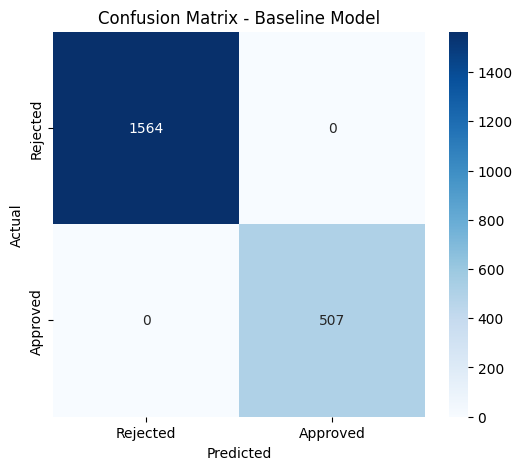

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Rejected","Approved"],
    yticklabels=["Rejected","Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Model")

plt.show()

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1564
         1.0       1.00      1.00      1.00       507

    accuracy                           1.00      2071
   macro avg       1.00      1.00      1.00      2071
weighted avg       1.00      1.00      1.00      2071



In [22]:
# Create a copy for preprocessing
df_clean = df.copy()
df_clean.drop(columns=["Unnamed: 0", "id", "year"], inplace=True)
missing = df_clean.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

cat_cols = df_clean.select_dtypes(include=['object']).columns

print("Numerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)
for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

df_clean.isnull().sum().sum()


Numerical Columns
Index(['loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'property_value', 'income', 'credit_score',
       'ltv', 'status', 'dtir1', 'high_interest_rate', 'senior_age'],
      dtype='object')

Categorical Columns
Index(['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'credit_worthiness', 'open_credit', 'business_or_commercial',
       'neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'region', 'security_type'],
      dtype='object')


np.int64(0)

In [23]:
!pip install xgboost -q
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability (needed for ROC AUC)
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    return [accuracy, precision, recall, f1, roc]

In [79]:
from sklearn.model_selection import train_test_split

X_base = df_base.drop("status", axis=1)
y_base = df_base["status"]

# Separate numerical and categorical columns for X_base
num_cols_base = X_base.select_dtypes(include=['int64', 'float64']).columns
cat_cols_base = X_base.select_dtypes(include=['object']).columns

# Fill numerical missing values with median for X_base
for col in num_cols_base:
    X_base[col].fillna(X_base[col].median(), inplace=True)

# Fill categorical missing values with mode for X_base
for col in cat_cols_base:
    X_base[col].fillna(X_base[col].mode()[0], inplace=True)

# One-hot encode categorical features for X_base
X_base = pd.get_dummies(X_base, drop_first=True)
# Rename columns to make them XGBoost compatible
X_base.columns = (
    X_base.columns
    .str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)
)

# Filter out rows where y_base has NaN values
not_nan_mask_base = y_base.notna()
X_base_filtered = X_base[not_nan_mask_base]
y_base_filtered = y_base[not_nan_mask_base]

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base_filtered,
    y_base_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_base_filtered
)

In [80]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [81]:
before_results = {}

for name, model in models.items():

    before_results[name] = evaluate_model(
        model,
        X_train_base,
        X_test_base,
        y_train_base,
        y_test_base
    )

In [82]:
before_df = pd.DataFrame(
    before_results,
    index=["Accuracy","Precision","Recall","F1 Score","ROC AUC"]
).T

before_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.998551,1.0,0.994083,0.997033,0.998237
Random Forest,1.000000,1.0,1.000000,1.000000,1.000000
XGBoost,1.000000,1.0,1.000000,1.000000,1.000000


In [83]:
for col in X_base.columns:
    if "[" in col or "]" in col or "<" in col or ">" in col:
        print(col)

In [84]:
before_df.to_csv("Before_Preprocessing_Results.csv")

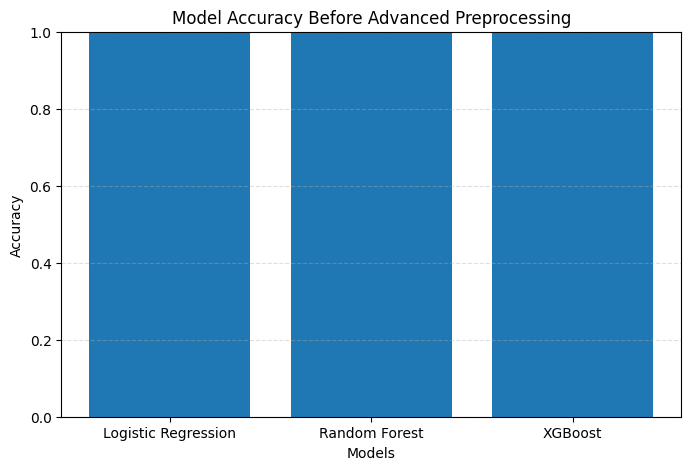

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(before_df.index, before_df["Accuracy"])

plt.title("Model Accuracy Before Advanced Preprocessing")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

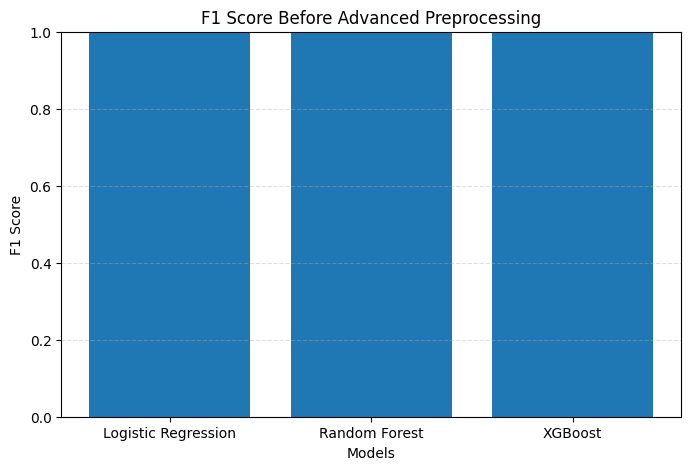

In [86]:
plt.figure(figsize=(8,5))

plt.bar(before_df.index, before_df["F1 Score"])

plt.title("F1 Score Before Advanced Preprocessing")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

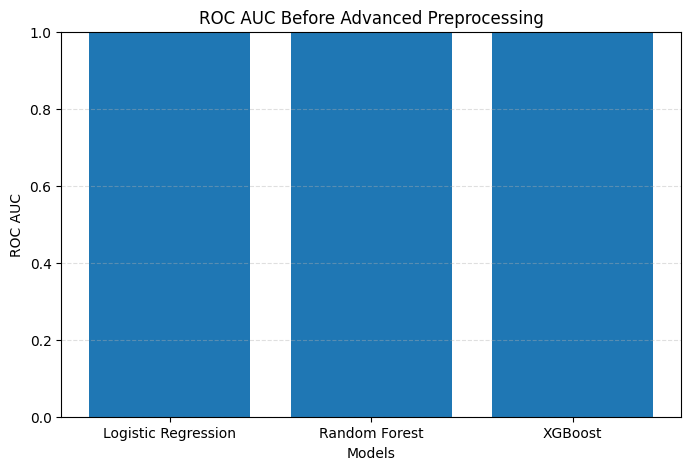

In [87]:
plt.figure(figsize=(8,5))

plt.bar(before_df.index, before_df["ROC AUC"])

plt.title("ROC AUC Before Advanced Preprocessing")
plt.xlabel("Models")
plt.ylabel("ROC AUC")

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

In [88]:
X_clean = df_clean.drop("status", axis=1)
y_clean = df_clean["status"]
X_clean = pd.get_dummies(X_clean, drop_first=True)

# Clean column names for XGBoost
X_clean.columns = (
    X_clean.columns
    .str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)
)
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)


In [89]:
after_results = {}

for name, model in models.items():

    after_results[name] = evaluate_model(
        model,
        X_train_clean,
        X_test_clean,
        y_train_clean,
        y_test_clean
    )

In [90]:
after_df = pd.DataFrame(
    after_results,
    index=["Accuracy","Precision","Recall","F1 Score","ROC AUC"]
).T

after_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.999034,1.0,0.996055,0.998024,0.998526
Random Forest,1.000000,1.0,1.000000,1.000000,1.000000
XGBoost,1.000000,1.0,1.000000,1.000000,1.000000


#EDA

In [91]:
df_clean.columns.tolist()

['loan_limit',
 'gender',
 'approv_in_adv',
 'loan_type',
 'loan_purpose',
 'credit_worthiness',
 'open_credit',
 'business_or_commercial',
 'loan_amount',
 'rate_of_interest',
 'interest_rate_spread',
 'upfront_charges',
 'term',
 'neg_ammortization',
 'interest_only',
 'lump_sum_payment',
 'property_value',
 'construction_type',
 'occupancy_type',
 'secured_by',
 'total_units',
 'income',
 'credit_type',
 'credit_score',
 'co-applicant_credit_type',
 'age',
 'submission_of_application',
 'ltv',
 'region',
 'security_type',
 'status',
 'dtir1',
 'high_interest_rate',
 'senior_age']

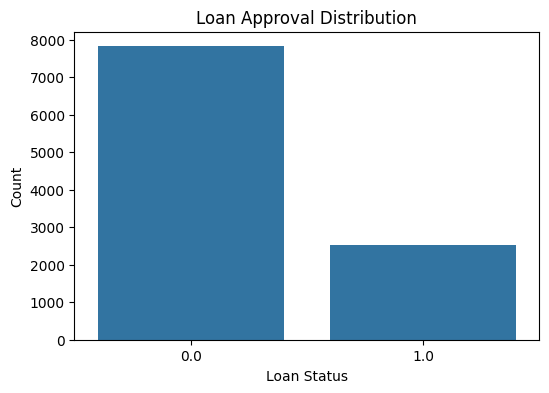

In [92]:
plt.figure(figsize=(6,4))

sns.countplot(x='status', data=df_clean)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

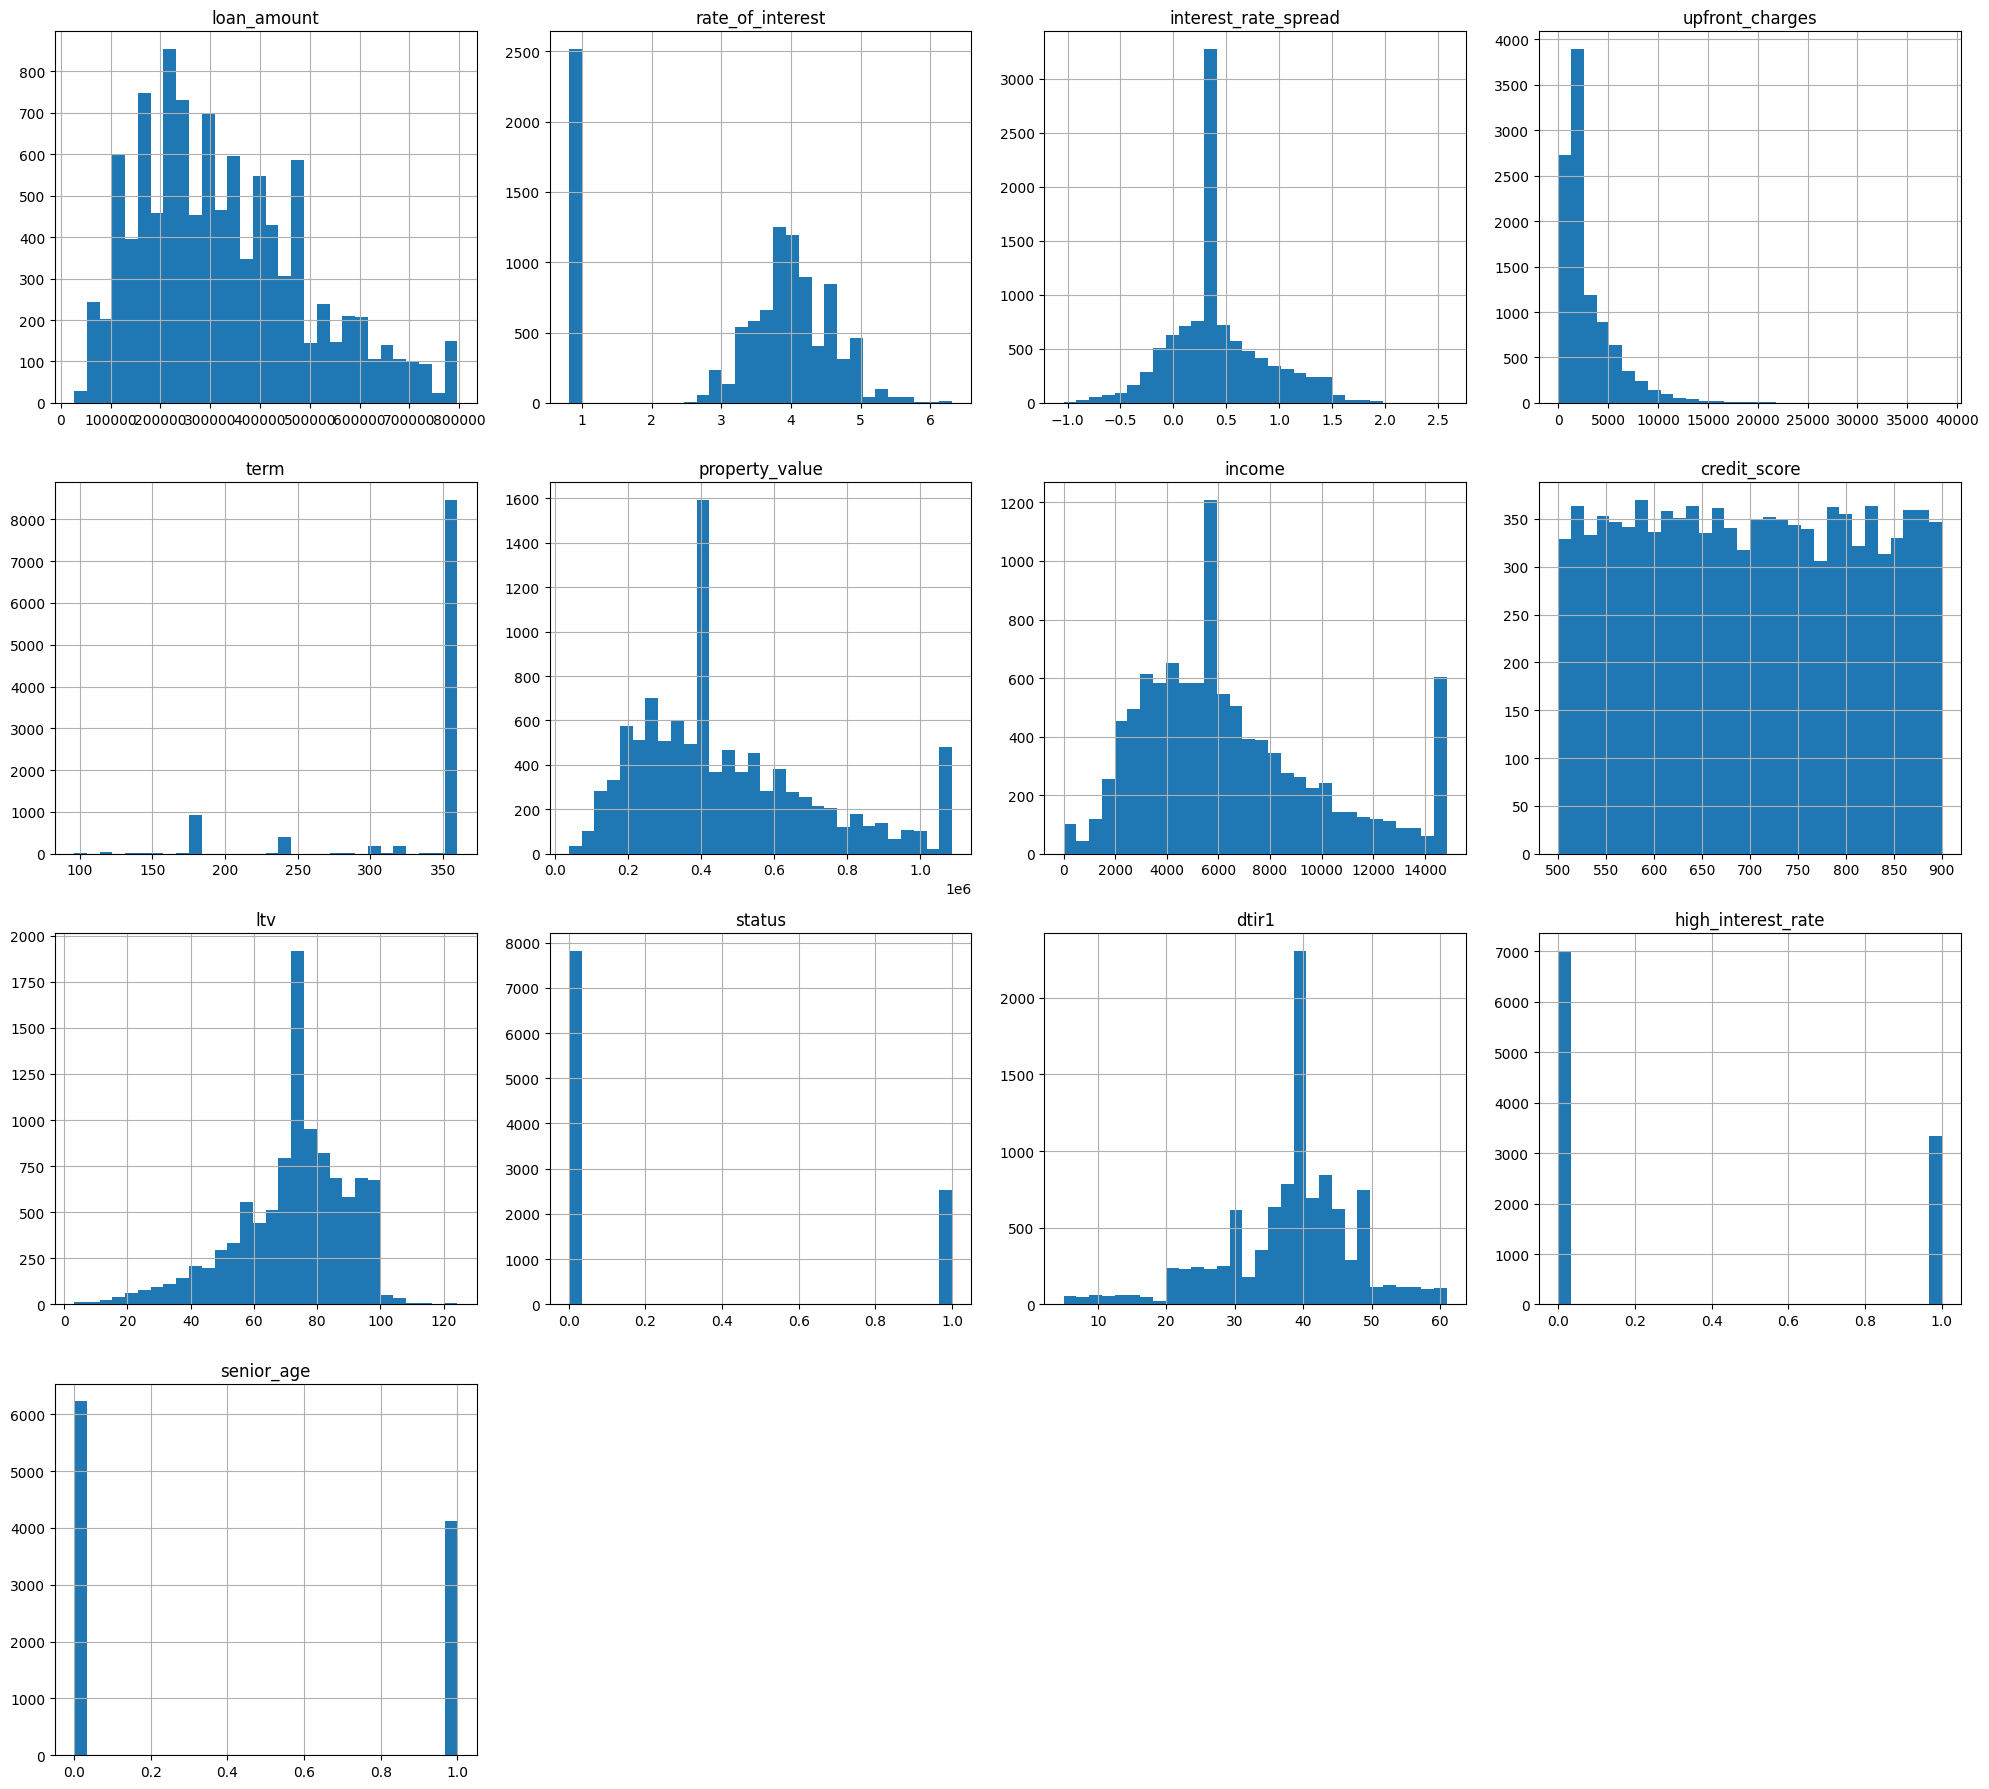

In [93]:
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

df_clean[num_cols].hist(figsize=(20,18), bins=30)

plt.tight_layout()

plt.show()

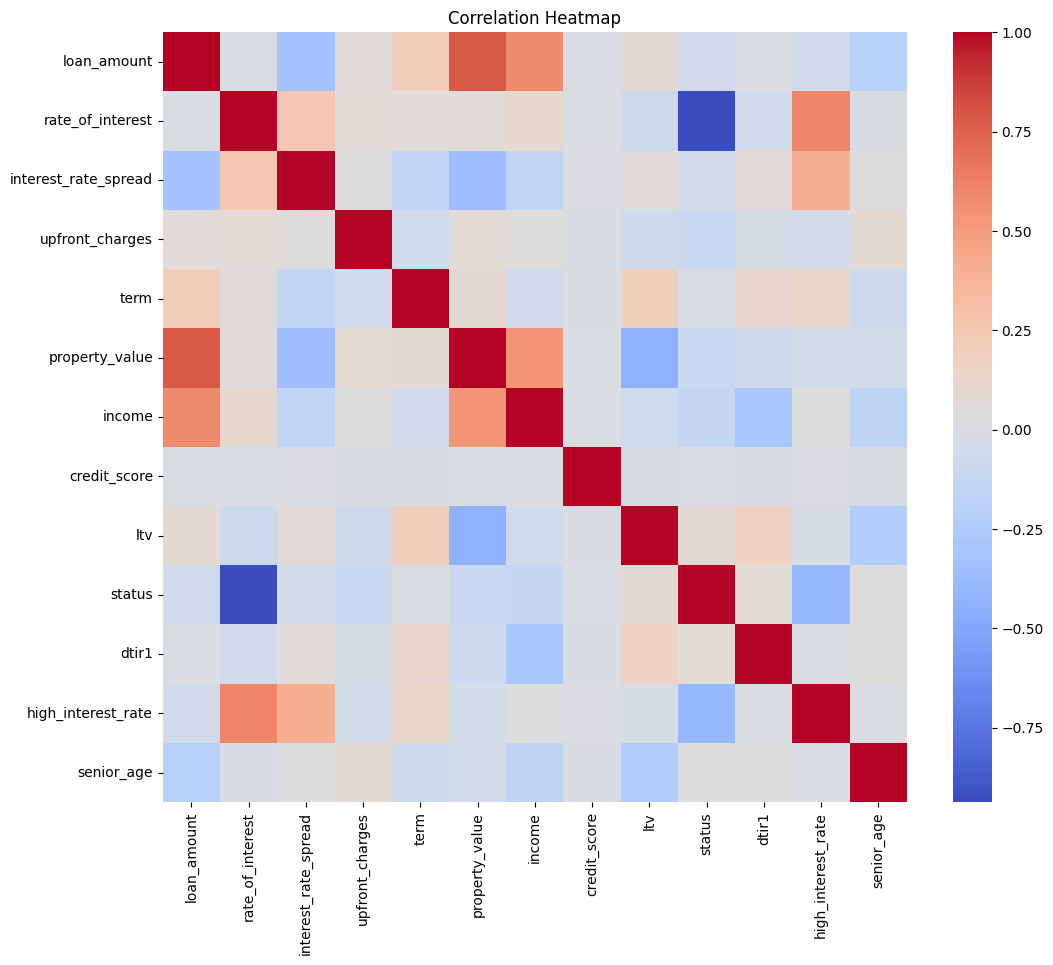

In [94]:
plt.figure(figsize=(12,10))

corr = df_clean.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

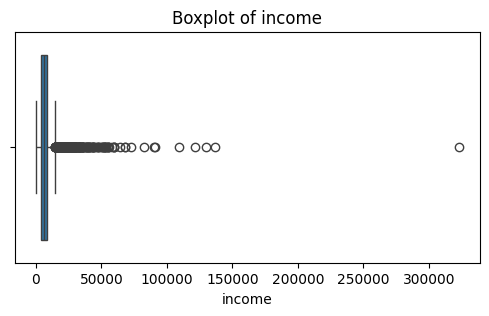

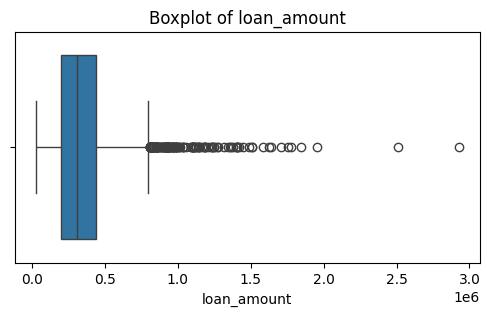

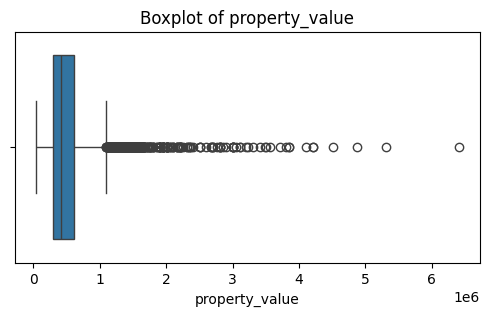

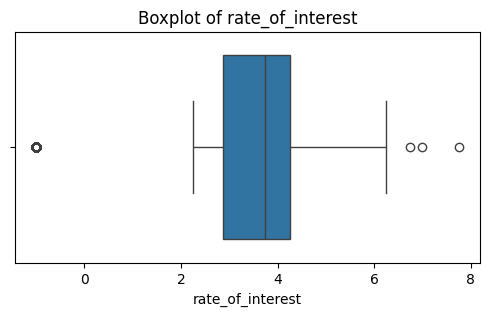

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df is defined (assuming it's loaded in a preceding cell, e.g., 'df = pd.read_csv("Loan.csv")')
# This block ensures df_clean is prepared if the notebook was run out of order or kernel restarted
df_clean = df.copy()
df_clean.drop(columns=["Unnamed: 0", "id", "year"], inplace=True)

num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

important_cols = [
    "income",
    "loan_amount",
    "property_value",
    "rate_of_interest"
]

for col in important_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df_clean[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

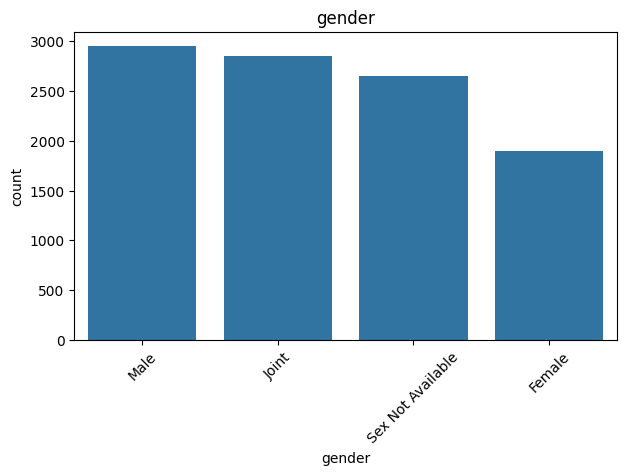

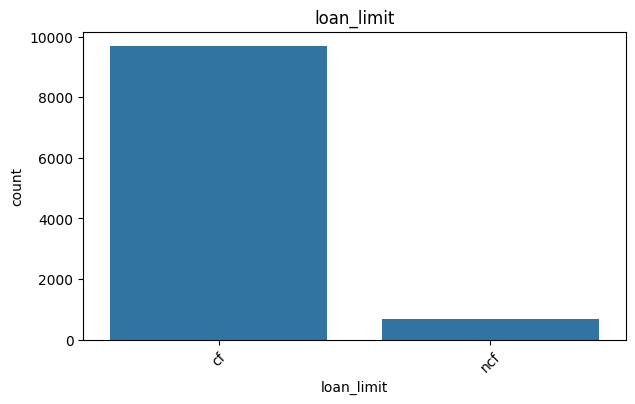

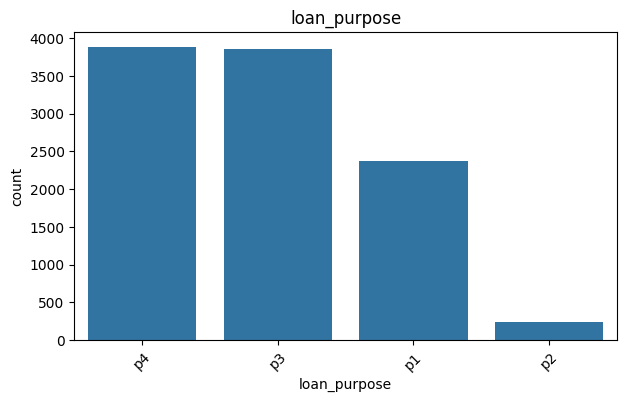

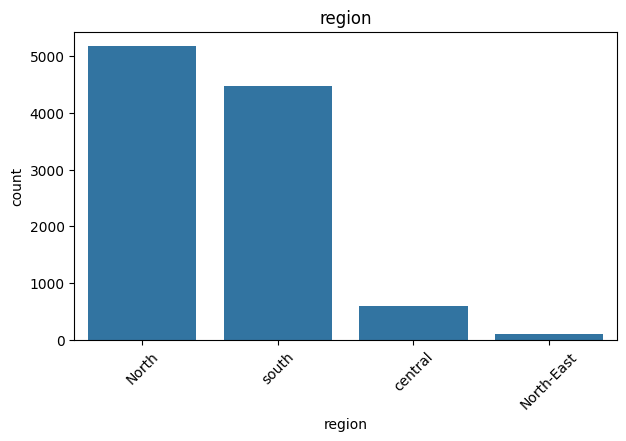

In [96]:
categorical_cols = [
    "gender",
    "loan_limit",
    "loan_purpose",
    "region"
]

for col in categorical_cols:

    plt.figure(figsize=(7,4))

    sns.countplot(
        x=df_clean[col],
        order=df_clean[col].value_counts().index
    )

    plt.xticks(rotation=45)

    plt.title(col)

    plt.show()

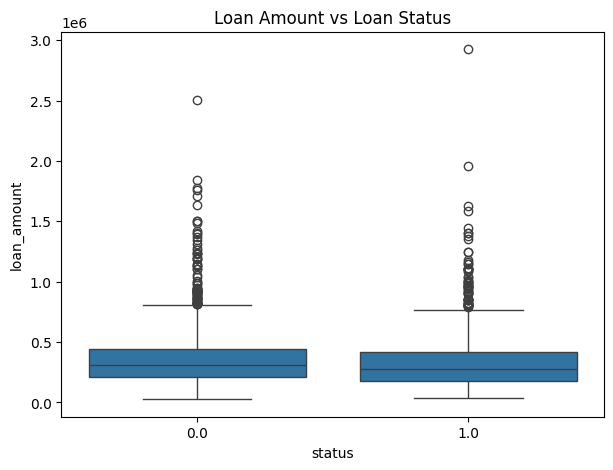

In [98]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="status",
    y="loan_amount",
    data=df_clean
)

plt.title("Loan Amount vs Loan Status")

plt.show()

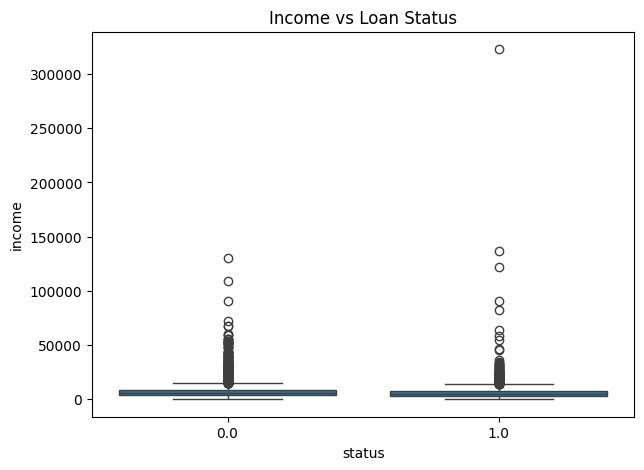

In [99]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="status",
    y="income",
    data=df_clean
)

plt.title("Income vs Loan Status")

plt.show()

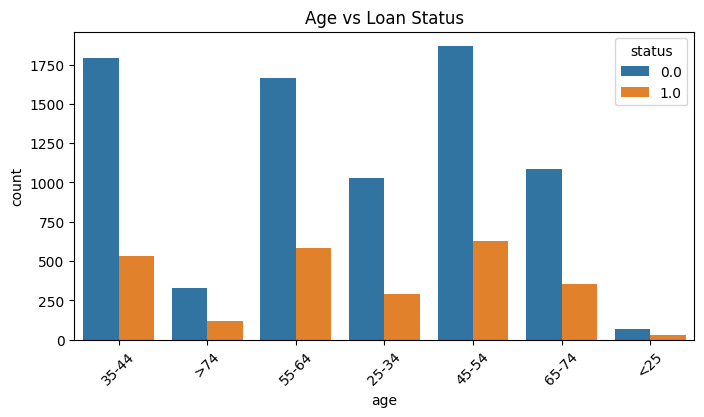

In [100]:
plt.figure(figsize=(8,4))

sns.countplot(
    x="age",
    hue="status",
    data=df_clean
)

plt.xticks(rotation=45)

plt.title("Age vs Loan Status")

plt.show()

In [101]:
# Columns where IQR makes sense
iqr_cols = [
    "income",
    "loan_amount",
    "property_value",
    "rate_of_interest"
]

for col in iqr_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df_clean[col] < lower) |
                (df_clean[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

income: 540 outliers
loan_amount: 139 outliers
property_value: 449 outliers
rate_of_interest: 2519 outliers


In [102]:
for col in iqr_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean[col] = df_clean[col].clip(lower, upper)

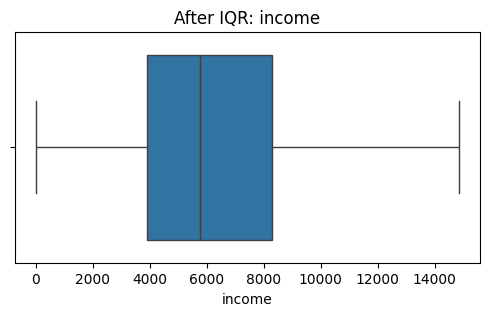

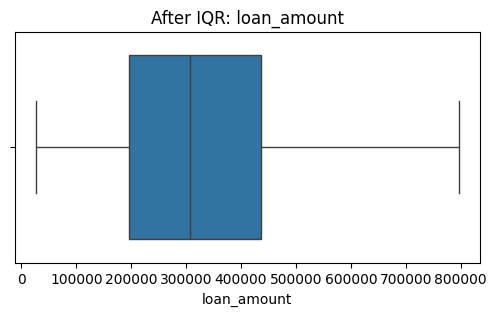

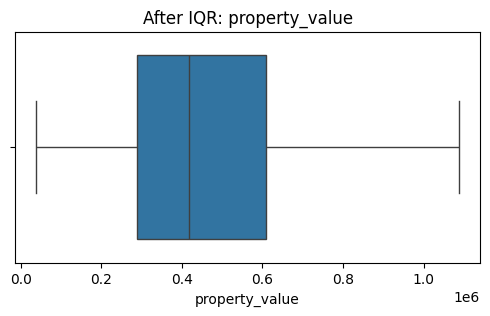

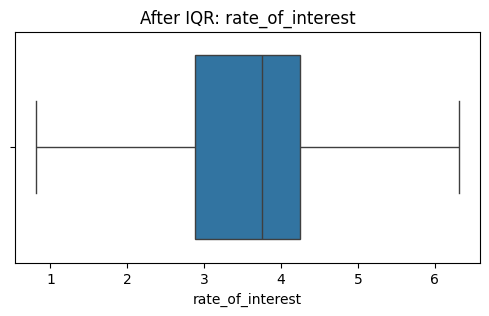

In [103]:
for col in iqr_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_clean[col])
    plt.title(f"After IQR: {col}")
    plt.show()

In [104]:
from sklearn.preprocessing import StandardScaler

X_clean = df_clean.drop("status", axis=1)
y_clean = df_clean["status"]

# Handle categorical variables
X_clean = pd.get_dummies(X_clean, drop_first=True)
X_clean.columns = X_clean.columns.str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)

scaler = StandardScaler()

X_clean_scaled = scaler.fit_transform(X_clean)

In [105]:
X_clean = df_clean.drop("status", axis=1)
y_clean = df_clean["status"]

# Remove rows where target is missing
mask = y_clean.notna()
X_clean = X_clean[mask]
y_clean = y_clean[mask]

# Fill remaining missing values
for col in X_clean.select_dtypes(include=["int64","float64"]).columns:
    X_clean[col] = X_clean[col].fillna(X_clean[col].median())

for col in X_clean.select_dtypes(include=["object"]).columns:
    X_clean[col] = X_clean[col].fillna(X_clean[col].mode()[0])

# One-hot encode categorical columns
X_clean = pd.get_dummies(X_clean, drop_first=True)

# Clean column names for XGBoost
X_clean.columns = (
    X_clean.columns
    .str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)
)

In [106]:
print(df_clean.columns.tolist())

['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'credit_worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'interest_rate_spread', 'upfront_charges', 'term', 'neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'secured_by', 'total_units', 'income', 'credit_type', 'credit_score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'ltv', 'region', 'security_type', 'status', 'dtir1', 'high_interest_rate', 'senior_age']


In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_clean_scaled = scaler.fit_transform(X_clean)

In [108]:
X_clean = df_clean.drop("status", axis=1)
y_clean = df_clean["status"]
mask = y_clean.notna()

X_clean = X_clean[mask]
y_clean = y_clean[mask]

In [109]:
X_clean = pd.get_dummies(
    X_clean,
    drop_first=True
)

X_clean.columns = (
    X_clean.columns
    .str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)
)

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_clean_scaled = scaler.fit_transform(X_clean)

In [111]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean_scaled,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

<Figure size 1000x500 with 0 Axes>

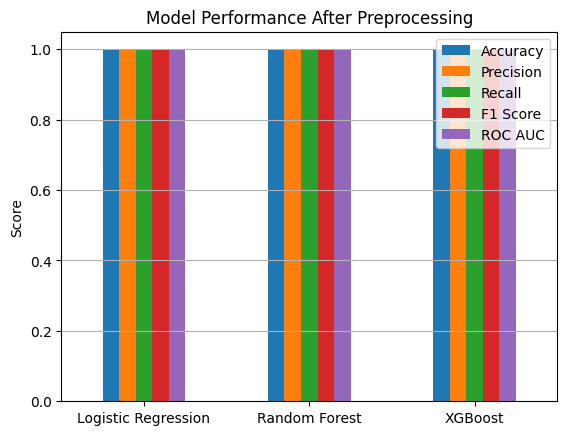

In [116]:
plt.figure(figsize=(10,5))

after_df.plot(kind="bar")

plt.title("Model Performance After Preprocessing")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

In [117]:
comparison = pd.DataFrame({
    "Before Accuracy": before_df["Accuracy"],
    "After Accuracy": after_df["Accuracy"],

    "Before F1": before_df["F1 Score"],
    "After F1": after_df["F1 Score"],

    "Before ROC": before_df["ROC AUC"],
    "After ROC": after_df["ROC AUC"]
})

comparison

,Before Accuracy,After Accuracy,Before F1,After F1,Before ROC,After ROC
Logistic Regression,0.998551,1.0,0.997033,1.0,0.998237,1.0
Random Forest,1.000000,1.0,1.000000,1.0,1.000000,1.0
XGBoost,1.000000,1.0,1.000000,1.0,1.000000,1.0


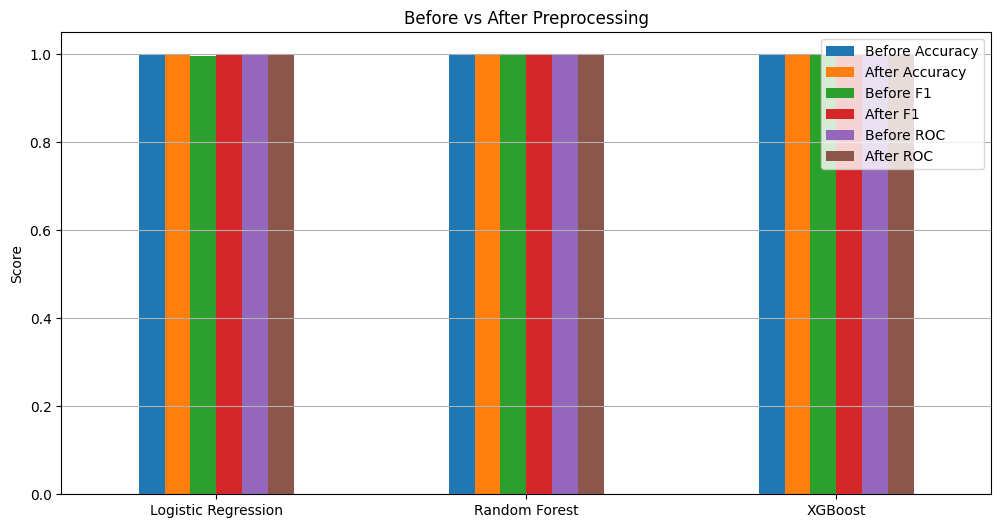

In [118]:
comparison.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Before vs After Preprocessing")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

In [119]:
before_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.998551,1.0,0.994083,0.997033,0.998237
Random Forest,1.000000,1.0,1.000000,1.000000,1.000000
XGBoost,1.000000,1.0,1.000000,1.000000,1.000000


In [120]:
after_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,1.0,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0,1.0,1.0


In [122]:
comparison

,Before Accuracy,After Accuracy,Before F1,After F1,Before ROC,After ROC
Logistic Regression,0.998551,1.0,0.997033,1.0,0.998237,1.0
Random Forest,1.000000,1.0,1.000000,1.0,1.000000,1.0
XGBoost,1.000000,1.0,1.000000,1.0,1.000000,1.0


In [123]:
print(before_df.index)
print(after_df.index)

Index(['Logistic Regression', 'Random Forest', 'XGBoost'], dtype='object')
Index(['Logistic Regression', 'Random Forest', 'XGBoost'], dtype='object')


In [125]:
print(df_clean["status"].value_counts())
print(df_clean.shape)
print(X_train_clean.shape)
print(X_test_clean.shape)
print(df_clean.head())

status
0.0    7821
1.0    2533
Name: count, dtype: int64
(10354, 34)
(8283, 51)
(2071, 51)
  loan_limit             gender approv_in_adv loan_type loan_purpose  \
0        ncf               Male         nopre     type1           p3   
1         cf              Joint         nopre     type1           p4   
2         cf  Sex Not Available         nopre     type1           p3   
3         cf             Female         nopre     type1           p3   
4         cf               Male         nopre     type1           p1   

  credit_worthiness open_credit business_or_commercial  loan_amount  \
0                l1        nopc                  nob/c       796500   
1                l1        nopc                  nob/c       406500   
2                l1        nopc                  nob/c       166500   
3                l1        nopc                  nob/c       206500   
4                l1        nopc                  nob/c       166500   

   rate_of_interest  ...  co-applicant_credit_typ

In [126]:
print(X_clean.columns)
print(X_clean.shape)
for col in X_clean.columns:
    if "status" in col.lower():
        print(col)
print(df_clean.duplicated().sum())

Index(['loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'property_value', 'income', 'credit_score',
       'ltv', 'dtir1', 'high_interest_rate', 'senior_age', 'loan_limit_ncf',
       'gender_Joint', 'gender_Male', 'gender_Sex_Not_Available',
       'approv_in_adv_pre', 'loan_type_type2', 'loan_type_type3',
       'loan_purpose_p2', 'loan_purpose_p3', 'loan_purpose_p4',
       'credit_worthiness_l2', 'open_credit_opc',
       'business_or_commercial_nob_c', 'neg_ammortization_not_',
       'neg_ammortization_not_neg', 'interest_only_not_int',
       'lump_sum_payment_not_lpsm', 'construction_type_sb',
       'occupancy_type_pr', 'occupancy_type_sr', 'secured_by_land',
       'total_units_2U', 'total_units_3U', 'total_units_4U',
       'credit_type_CRIF', 'credit_type_EQUI', 'credit_type_EXP',
       'co_applicant_credit_type_EXP', 'age_35_44', 'age_45_54', 'age_55_64',
       'age_65_74', 'age__25', 'age__74', 'submission_of_application_to_in

In [127]:
print(df_clean.shape)

(10354, 34)


In [128]:
print(df.shape)

(10354, 37)


In [129]:
print(df.shape)

print(df_clean.shape)

print(df_clean.isnull().sum().sum())

(10354, 37)
(10354, 34)
0
